In [8]:
import yfinance as yf 
import pandas as pd 

brent = yf.download("BZ=F", start="2020-01-01", end=None) 
brent.head

[*********************100%***********************]  1 of 1 completed


<bound method NDFrame.head of Price           Close       High        Low       Open Volume
Ticker           BZ=F       BZ=F       BZ=F       BZ=F   BZ=F
Date                                                         
2020-01-02  66.250000  66.570000  65.730003  66.470001  25810
2020-01-03  68.599998  69.480003  66.220001  66.290001  78848
2020-01-06  68.910004  70.720001  68.190002  69.070000  51933
2020-01-07  68.269997  68.739998  67.650002  68.580002  41178
2020-01-08  65.440002  71.989998  64.940002  68.470001  85232
...               ...        ...        ...        ...    ...
2026-07-15  84.949997  86.529999  83.339996  85.209999  52882
2026-07-16  84.230003  86.260002  83.830002  85.220001  39917
2026-07-17  88.099998  88.320000  83.709999  84.889999  30997
2026-07-20  89.220001  91.430000  86.139999  89.010002  30997
2026-07-21  88.790001  89.410004  87.879997  88.889999   5354

[1648 rows x 5 columns]>

In [9]:
brent.info

<bound method DataFrame.info of Price           Close       High        Low       Open Volume
Ticker           BZ=F       BZ=F       BZ=F       BZ=F   BZ=F
Date                                                         
2020-01-02  66.250000  66.570000  65.730003  66.470001  25810
2020-01-03  68.599998  69.480003  66.220001  66.290001  78848
2020-01-06  68.910004  70.720001  68.190002  69.070000  51933
2020-01-07  68.269997  68.739998  67.650002  68.580002  41178
2020-01-08  65.440002  71.989998  64.940002  68.470001  85232
...               ...        ...        ...        ...    ...
2026-07-15  84.949997  86.529999  83.339996  85.209999  52882
2026-07-16  84.230003  86.260002  83.830002  85.220001  39917
2026-07-17  88.099998  88.320000  83.709999  84.889999  30997
2026-07-20  89.220001  91.430000  86.139999  89.010002  30997
2026-07-21  88.790001  89.410004  87.879997  88.889999   5354

[1648 rows x 5 columns]>

In [10]:
brent.describe

<bound method NDFrame.describe of Price           Close       High        Low       Open Volume
Ticker           BZ=F       BZ=F       BZ=F       BZ=F   BZ=F
Date                                                         
2020-01-02  66.250000  66.570000  65.730003  66.470001  25810
2020-01-03  68.599998  69.480003  66.220001  66.290001  78848
2020-01-06  68.910004  70.720001  68.190002  69.070000  51933
2020-01-07  68.269997  68.739998  67.650002  68.580002  41178
2020-01-08  65.440002  71.989998  64.940002  68.470001  85232
...               ...        ...        ...        ...    ...
2026-07-15  84.949997  86.529999  83.339996  85.209999  52882
2026-07-16  84.230003  86.260002  83.830002  85.220001  39917
2026-07-17  88.099998  88.320000  83.709999  84.889999  30997
2026-07-20  89.220001  91.430000  86.139999  89.010002  30997
2026-07-21  88.790001  89.410004  87.879997  88.889999   5354

[1648 rows x 5 columns]>

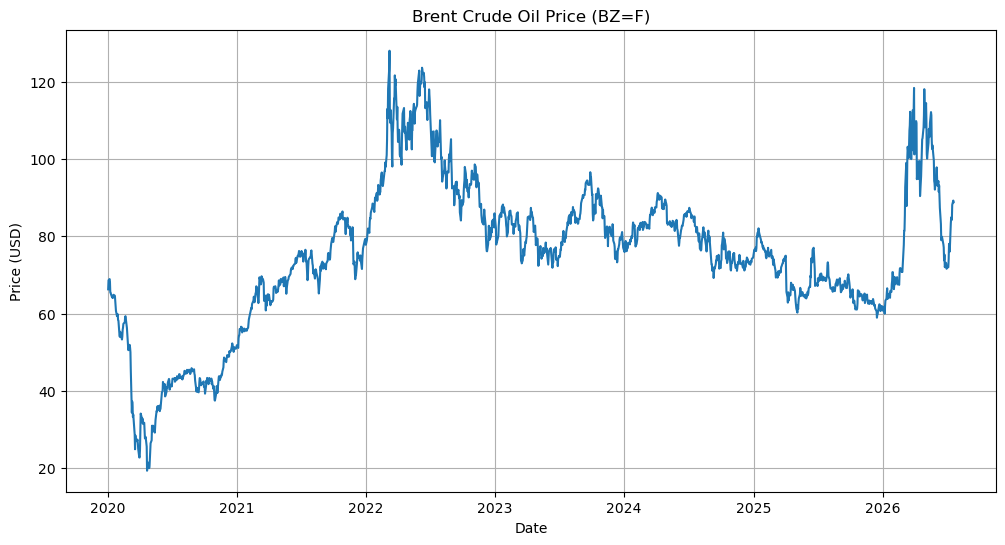

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(brent.index, brent ['Close'])
plt.title('Brent Crude Oil Price (BZ=F)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.grid(True)
plt.show()

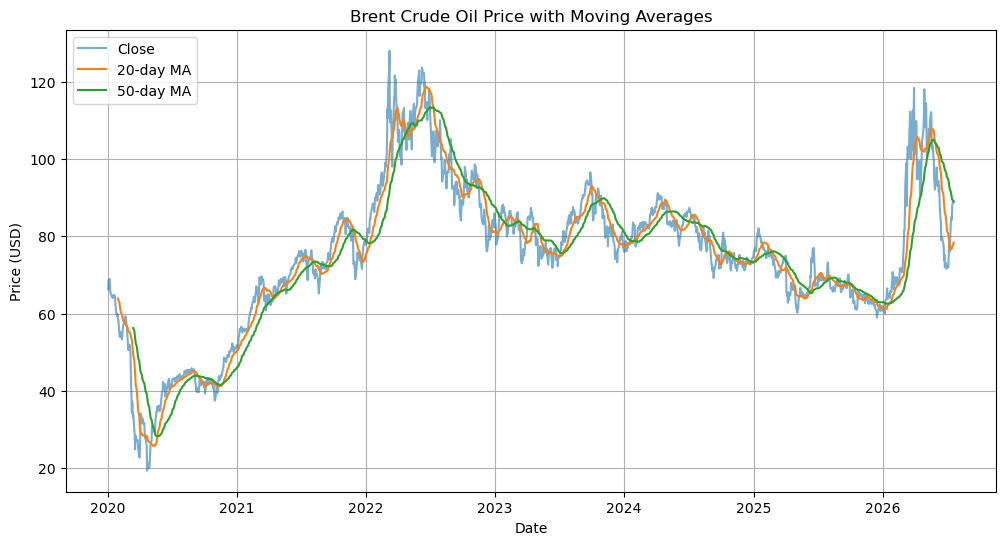

In [19]:
brent['MA20'] = brent['Close'].rolling(window=20).mean()
brent['MA50'] = brent['Close'].rolling(window=50).mean()

plt.figure(figsize=(12,6))
plt.plot(brent.index, brent['Close'], label='Close', alpha=0.6)
plt.plot(brent.index, brent['MA20'], label='20-day MA')
plt.plot(brent.index, brent['MA50'], label='50-day MA')
plt.title('Brent Crude Oil Price with Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.show()

In [26]:
print(brent.columns)
brent['Volatility_20'].head(30)
brent['Volatility_20'].isna().sum()


Index(['Close', 'High', 'Low', 'Open', 'Volume', 'MA20', 'MA50',
       'Daily_Return', 'Volatility_30', 'Volatility_20'],
      dtype='object', name='Price')


np.int64(1648)

In [27]:
brent.columns = brent.columns.get_level_values(0)

In [28]:
brent['Daily_Return'] = brent['Close'].pct_change()
brent['Volatility_20'] = brent['Daily_Return'].rolling(window=20).std()
brent['Volatility_20'].tail(10)

Date
2026-07-08    0.028675
2026-07-09    0.028434
2026-07-10    0.027767
2026-07-13    0.036015
2026-07-14    0.035558
2026-07-15    0.033816
2026-07-16    0.031634
2026-07-17    0.033015
2026-07-20    0.033049
2026-07-21    0.032381
Name: Volatility_20, dtype: float64

In [30]:
brent['Daily_Return'] = brent['Close'].pct_change()
brent['Daily_Return'].head(10)

Date
2020-01-02         NaN
2020-01-03    0.035472
2020-01-06    0.004519
2020-01-07   -0.009288
2020-01-08   -0.041453
2020-01-09   -0.001070
2020-01-10   -0.005966
2020-01-13   -0.012004
2020-01-14    0.004517
2020-01-15   -0.007598
Name: Daily_Return, dtype: float64

In [31]:
brent['Volatility_20'] = brent['Daily_Return'].rolling(window=20).std()

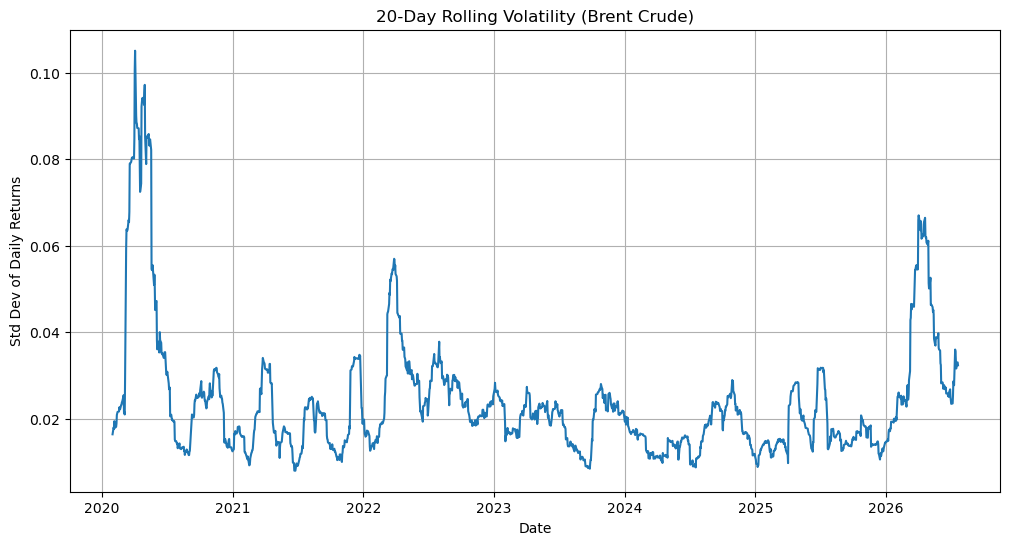

In [32]:
plt.figure(figsize=(12,6))
plt.plot(brent.index, brent['Volatility_20'])
plt.title('20-Day Rolling Volatility (Brent Crude)')
plt.xlabel('Date')
plt.ylabel('Std Dev of Daily Returns')
plt.grid(True)
plt.show()

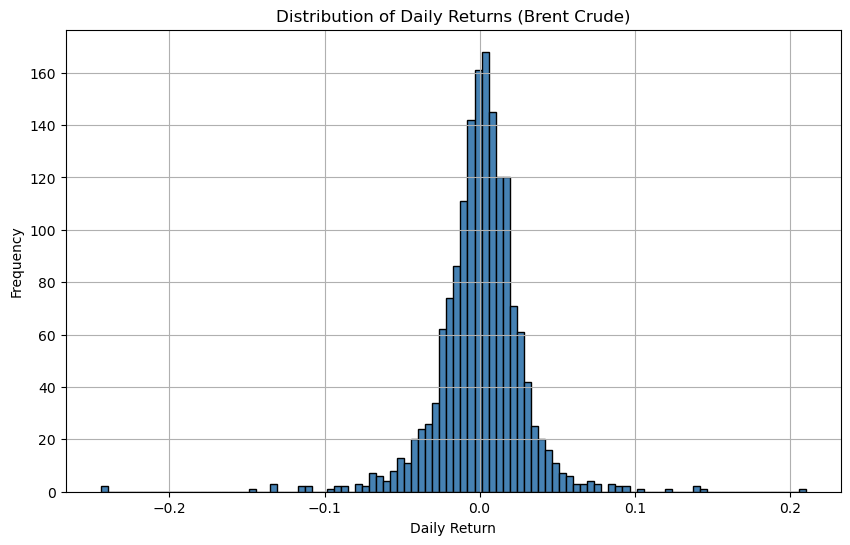

In [33]:
plt.figure(figsize=(10,6))
plt.hist(brent['Daily_Return'].dropna(), bins=100, color='steelblue', edgecolor='black')
plt.title('Distribution of Daily Returns (Brent Crude)')
plt.xlabel('Daily Return')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

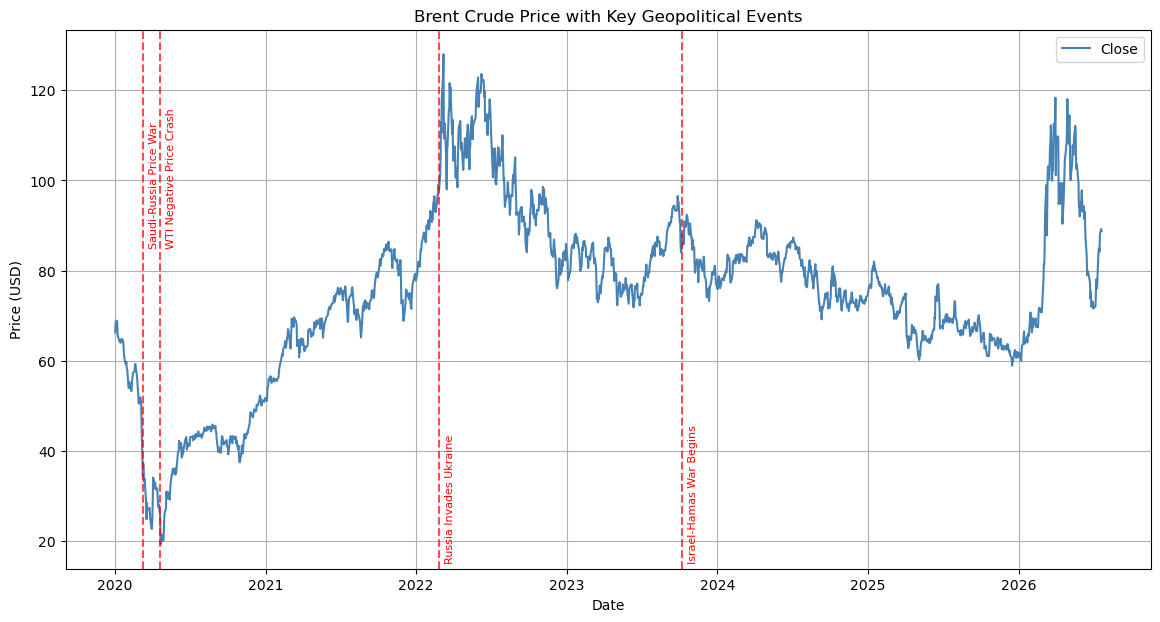

In [39]:
import pandas as pd

events = {
    '2020-03-09': 'Saudi-Russia Price War',
    '2020-04-20': 'WTI Negative Price Crash',
    '2022-02-24': 'Russia Invades Ukraine',
    '2023-10-07': 'Israel-Hamas War Begins',
}

plt.figure(figsize=(14,7))
plt.plot(brent.index, brent['Close'], label='Close', color='steelblue')

for date, label in events.items():
    date = pd.to_datetime(date)
    plt.axvline(date, color='red', linestyle='--', alpha=0.7)
    y_pos = 85 if '2020' in date.strftime('%Y') else 15
    plt.text(date + pd.Timedelta(days=15), y_pos, label, rotation=90, verticalalignment='bottom', fontsize=8, color='red')

plt.title('Brent Crude Price with Key Geopolitical Events')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.show()

[*********************100%***********************]  1 of 1 completed


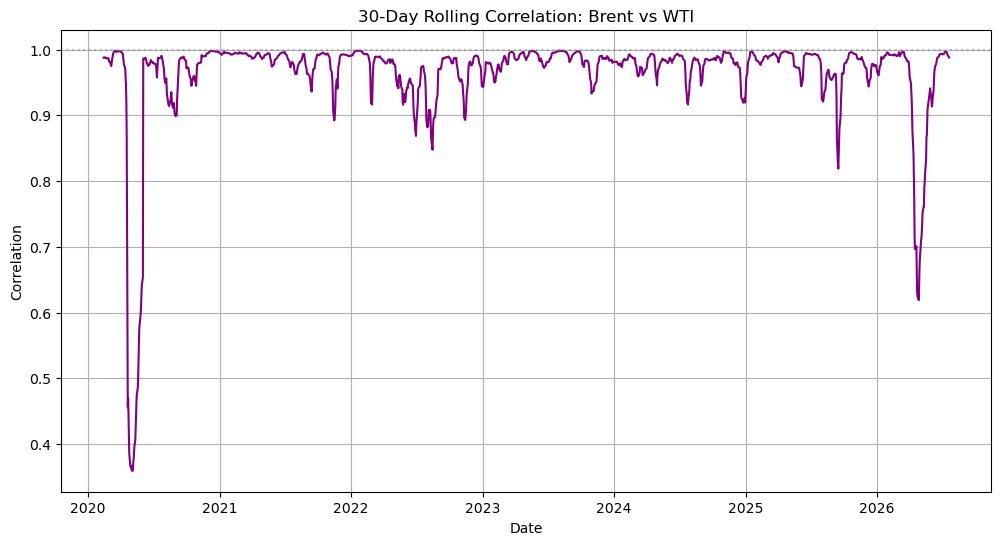

In [40]:
wti = yf.download("CL=F", start="2020-01-01", end=None)
wti.columns = wti.columns.get_level_values(0)  # flatten if MultiIndex

# align on shared dates
combined = pd.DataFrame({
    'Brent': brent['Close'],
    'WTI': wti['Close']
}).dropna()

combined['Rolling_Corr'] = combined['Brent'].rolling(window=30).corr(combined['WTI'])

plt.figure(figsize=(12,6))
plt.plot(combined.index, combined['Rolling_Corr'], color='purple')
plt.title('30-Day Rolling Correlation: Brent vs WTI')
plt.xlabel('Date')
plt.ylabel('Correlation')
plt.axhline(1, color='gray', linestyle=':', alpha=0.5)
plt.grid(True)
plt.show()